# Example 1 Cube Field 


In [150]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import cm

In [214]:
def compute_field_for_point_charge(x0, X, Y, Z):
    """compute the field induced by the unit point charge x in the scope

    Args:
        x (NdArray): (x0,y0,z0) coordinate of the charge 
        X/Y/Z (NdArray): meshgrid for scope
    """
    C = 4 * np.pi * sp.constants.epsilon_0
    #separation vector
    R_x = X - x0[0] 
    R_y = Y - x0[1]
    R_z = Z - x0[2]
    R = np.stack([R_x, R_y, R_z])
    mag = np.linalg.norm(R, ord=2, axis=0)
    mask = np.random.binomial(n=1, p=mag/(np.max(mag)+1e-8),size=X.shape)
    R = R * mask
    return R  / (C * mag)**3
        
        

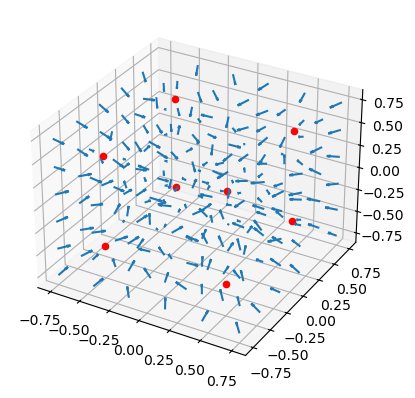

In [230]:
N_sample=6
scope = np.linspace(-0.75, 0.75, N_sample)
X, Y, Z = np.meshgrid(scope, scope, scope)
final_field = np.empty(shape=(3, N_sample, N_sample, N_sample))
fig, ax = plt.subplots(subplot_kw={'projection':'3d'}) 
for i in (-1/2,  1/2):
    for j in (-1/2,  1/2):
        for k in (-1/2,  1/2):
            final_field -=  compute_field_for_point_charge(np.array([i,j,k]), X, Y, Z)
            ax.scatter(i,j,k, c='r', marker='o')
ax.quiver(X, Y, Z,  final_field[0], final_field[1], final_field[2], normalize=True, length=1e-1)
plt.show()

/var/folders/rt/3dkh62n96hxd9jccg_nzsfkh0000gn/T/ipykernel_59832/86892290.py:17: RuntimeWarning: invalid value encountered in divide
  return R  / (C * mag)**3


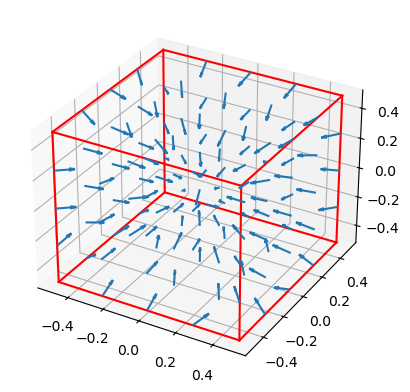

In [222]:
N_sample=5
scope = np.linspace(-0.5, 0.5, N_sample)
X, Y, Z = np.meshgrid(scope, scope, scope)
final_field = np.empty(shape=(3, N_sample, N_sample, N_sample))
fig, ax = plt.subplots(subplot_kw={'projection':'3d'}) 
resol = 1000
for i in (-1/2,  1/2):
    for j in (-1/2, 1/2):
        for k in np.linspace(-1/2, 1/2, resol):
            final_field -= compute_field_for_point_charge(np.array([k,i,j]), X, Y, Z)
            final_field -= compute_field_for_point_charge(np.array([i,k,j]), X, Y, Z)
            final_field -= compute_field_for_point_charge(np.array([i,j,k]), X, Y, Z)
            
        ax.plot(np.linspace(-1/2, 1/2, resol),i, j, c='r')
        ax.plot(i,np.linspace(-1/2, 1/2, resol), j, c='r')
        ax.plot(i,j,np.linspace(-1/2, 1/2, resol), c='r')
ax.quiver(X, Y, Z,  final_field[0], final_field[1], final_field[2], normalize=True, length=1e-1)
plt.show()

In [154]:
n=1e6
print(1/np.e - (1+1/n)**(-n))

-1.8396990814073533e-07
